In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
# Load training and testing data
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

print("Training documents:", len(train_data.data))
print("Testing documents :", len(test_data.data))
print("Number of topics   :", len(train_data.target_names))

print("\nTopics:")
print(train_data.target_names)

Training documents: 11314
Testing documents : 7532
Number of topics   : 20

Topics:
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [3]:
print("Sample document:")
print(train_data.data[0])

print("\nTopic:")
print(train_data.target_names[train_data.target[0]])

Sample document:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Topic:
rec.autos


In [4]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000
)

X_train = vectorizer.fit_transform(train_data.data)
X_test = vectorizer.transform(test_data.data)

y_train = train_data.target
y_test = test_data.target

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

Training feature shape: (11314, 20000)
Testing feature shape : (7532, 20000)


In [5]:
mnb = MultinomialNB()

mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
f1_mnb = f1_score(y_test, y_pred_mnb, average="weighted")

print("Multinomial Naïve Bayes")
print("----------------------")
print("Accuracy :", round(accuracy_mnb, 4))
print("F1-score :", round(f1_mnb, 4))

Multinomial Naïve Bayes
----------------------
Accuracy : 0.6807
F1-score : 0.6677


In [6]:
bnb = BernoulliNB()

bnb.fit(X_train, y_train)

y_pred_bnb = bnb.predict(X_test)

accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
f1_bnb = f1_score(y_test, y_pred_bnb, average="weighted")

print("Bernoulli Naïve Bayes")
print("---------------------")
print("Accuracy :", round(accuracy_bnb, 4))
print("F1-score :", round(f1_bnb, 4))

Bernoulli Naïve Bayes
---------------------
Accuracy : 0.5005
F1-score : 0.5025


In [7]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naïve Bayes",
        "Bernoulli Naïve Bayes"
    ],
    "Accuracy": [
        accuracy_mnb,
        accuracy_bnb
    ],
    "F1-Score": [
        f1_mnb,
        f1_bnb
    ]
})

print(results)

                     Model  Accuracy  F1-Score
0  Multinomial Naïve Bayes  0.680696  0.667691
1    Bernoulli Naïve Bayes  0.500531  0.502474


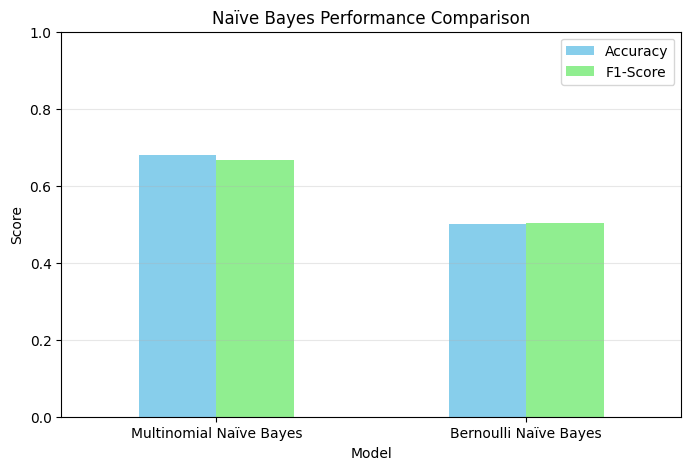

===== MULTINOMIAL NAÏVE BAYES =====
                          precision    recall  f1-score   support

             alt.atheism       0.67      0.23      0.34       319
           comp.graphics       0.64      0.69      0.67       389
 comp.os.ms-windows.misc       0.65      0.60      0.62       394
comp.sys.ibm.pc.hardware       0.61      0.73      0.66       392
   comp.sys.mac.hardware       0.77      0.68      0.72       385
          comp.windows.x       0.81      0.76      0.78       395
            misc.forsale       0.77      0.78      0.77       390
               rec.autos       0.79      0.72      0.76       396
         rec.motorcycles       0.83      0.75      0.79       398
      rec.sport.baseball       0.91      0.80      0.85       397
        rec.sport.hockey       0.56      0.92      0.70       399
               sci.crypt       0.66      0.78      0.72       396
         sci.electronics       0.70      0.53      0.60       393
                 sci.med       0.86    

In [9]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5),
    color=["skyblue", "lightgreen"]
)

plt.title("Naïve Bayes Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()
print("===== MULTINOMIAL NAÏVE BAYES =====")
print(
    classification_report(
        y_test,
        y_pred_mnb,
        target_names=test_data.target_names
    )
)

print("\n===== BERNOULLI NAÏVE BAYES =====")
print(
    classification_report(
        y_test,
        y_pred_bnb,
        target_names=test_data.target_names
    )
)

In [10]:
print("========== FINAL COMPARISON ==========")

if accuracy_mnb > accuracy_bnb:
    print("Multinomial Naïve Bayes has higher accuracy.")
elif accuracy_bnb > accuracy_mnb:
    print("Bernoulli Naïve Bayes has higher accuracy.")
else:
    print("Both models have the same accuracy.")

if f1_mnb > f1_bnb:
    print("Multinomial Naïve Bayes has higher F1-score.")
elif f1_bnb > f1_mnb:
    print("Bernoulli Naïve Bayes has higher F1-score.")
else:
    print("Both models have the same F1-score.")

========== FINAL COMPARISON ==========
Multinomial Naïve Bayes has higher accuracy.
Multinomial Naïve Bayes has higher F1-score.
